In [1]:
#Packages
import pandas as pd
import re
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Cleaning
def clean_and_normalize_speaker_text(text):
    """Purifies dialogue rows by removing markdown noise and excessive whitespace."""
    if not isinstance(text, str) or pd.isna(text):
        return ""
    #Strips URL structures and HTML artifacts from transcript exports
    cleaned = re.sub(r'https?://\S+|www\.\S+', '', text)
    cleaned = re.sub(r'<.*?>', '', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return cleaned.strip()

#Input Structuring
def process_speaker_row(ticker, speaker, role, speaker_text, max_words=1125):
   
    clean_ticker = str(ticker).strip().upper()
    clean_speaker = str(speaker).strip() if pd.notna(speaker) else "Unknown Speaker"
    clean_role = str(role).strip() if pd.notna(role) else "Participant"
    
    #Constructs an informative title header natively from row metadata
    constructed_title = f"{clean_ticker} Call - {clean_speaker} ({clean_role})"
    
    raw_text = clean_and_normalize_speaker_text(speaker_text)
    if not raw_text:
        return ""
        
    words = raw_text.split(' ')
    
    #Conditional Check: If row is short, pass it through natively
    if len(words) <= max_words:
        return f"TITLE: {constructed_title} | SPEAKER_CONTEXT: {raw_text}"
        
    #Fallback Path: Handles long rows by slicing them
    sliced_words = words[:max_words]
    sliced_text = " ".join(sliced_words)
    return f"TITLE: {constructed_title} | SLICED_SPEAKER_CONTEXT: {sliced_text}"

In [3]:
#Processing
def transcript_pipeline(df, ticker_col='ticker', speaker_col='speaker', role_col='role', text_col='text'):

    df['gpt_input'] = df.apply(
        lambda row: process_speaker_row(
            ticker=row[ticker_col],
            speaker=row[speaker_col],
            role=row[role_col],
            speaker_text=row[text_col],
            max_words=1125
        ), axis=1
    )

In [4]:
#Data - Cleaned Transcripts Data
df_granular = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\ECT_Granular.csv")

In [5]:
#Execution
transcript_pipeline(df_granular)

In [6]:
df_granular.head(2)

,ticker,fiscal_year,fiscal_quarter,calendar_date,company_name,sector,section_type,speaker,role,turn_order,text,turn_word_count,transcript_total_words,gpt_input
0,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Operator,moderator,1,"Good day, ladies and gentlemen and thank you f...",47,10399,TITLE: ADSK Call - Operator (moderator) | SPEA...
1,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Abhey Lamba,executive,2,"Thanks, operator, and good afternoon. Thank yo...",233,10399,TITLE: ADSK Call - Abhey Lamba (executive) | S...


In [7]:
len(df_granular[df_granular['role'] == 'moderator'])

3510

Similar to pre-processing strategy for ML models, the operator rows will be dropped as they do not add sentimental value. The 3510 rows will be eliminated.

In [8]:
granular_final = df_granular[df_granular['role'] != 'moderator']
granular_final = granular_final.reset_index()

In [9]:
len(df_granular) - len(granular_final) #Confirms only moderator rows were dropped

3510

In [10]:
granular_final.head(2)

,index,ticker,fiscal_year,fiscal_quarter,calendar_date,company_name,sector,section_type,speaker,role,turn_order,text,turn_word_count,transcript_total_words,gpt_input
0,1,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Abhey Lamba,executive,2,"Thanks, operator, and good afternoon. Thank yo...",233,10399,TITLE: ADSK Call - Abhey Lamba (executive) | S...
1,2,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Andrew Anagnost,executive,3,"Thanks, Abhey. We started off fiscal '20 with ...",213,10399,TITLE: ADSK Call - Andrew Anagnost (executive)...


In [11]:
#Adding Processed word counts
granular_final['gpt_input_len'] = granular_final['gpt_input'].apply(lambda x:len(x.split()))

In [12]:
#Counts Statistics
display(granular_final['gpt_input_len'].describe().loc[['min', 'mean', 'max']])

min       14.000000
mean     186.331984
max     1136.000000
Name: gpt_input_len, dtype: float64

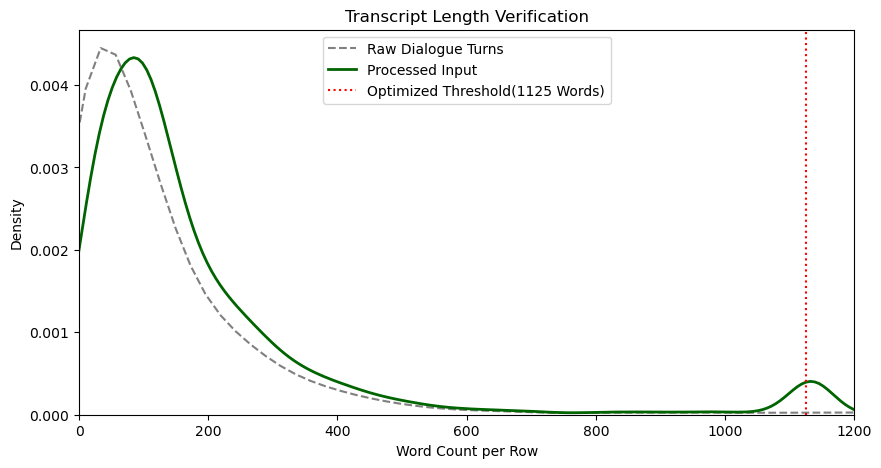

In [18]:
#length of the original text vs the processed text
plt.figure(figsize=(10, 5))
sns.kdeplot(df_granular['turn_word_count'], label='Raw Dialogue Turns', color='gray', linestyle='--')
sns.kdeplot(granular_final['gpt_input_len'], label='Processed Input', color='darkgreen', lw=2)
plt.axvline(x=1125, color='red', linestyle=':', label='Optimized Threshold(1125 Words)')
plt.xlim(0, 1200)
plt.title('Transcript Length Verification', fontsize=12)
plt.xlabel('Word Count per Row')
plt.ylabel('Density')
plt.legend()
plt.savefig('ECT_GPT_length_verification.png', dpi=300)
plt.show()

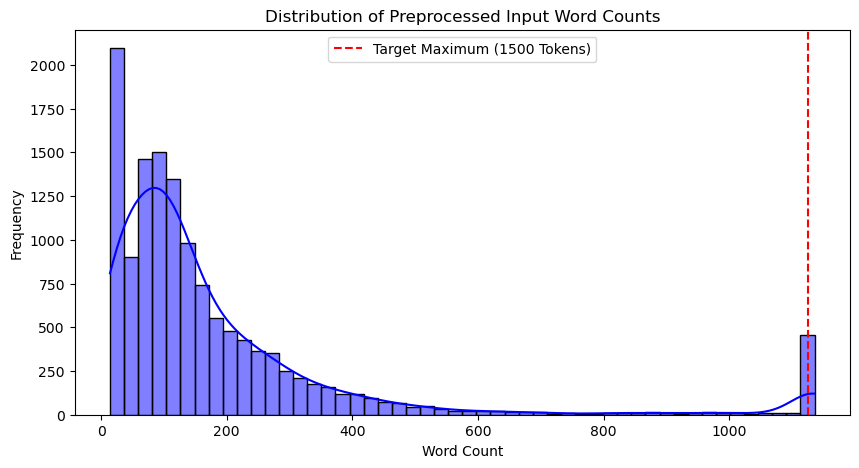

In [19]:
#Word count distribution
plt.figure(figsize=(10, 5))
sns.histplot(granular_final['gpt_input_len'], bins=50, kde=True, color='blue')
plt.axvline(x=1125, color='red', linestyle='--', label='Target Maximum (1500 Tokens)')
plt.title('Distribution of Preprocessed Input Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('ECT_GPTinput_distribution.png', dpi=300)
plt.show()